In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import sys

# Locate viscosity_pipeline_helper.py in ../results/Auto-runs (no edits to helper).
notebook_dir = Path.cwd()
candidate_dirs = [
    notebook_dir,
    notebook_dir.parent / 'results' / 'Auto-runs',
    notebook_dir / 'results' / 'Auto-runs',
    notebook_dir.parent.parent / 'results' / 'Auto-runs',
]
helper_dir = next((d for d in candidate_dirs if (d / 'viscosity_pipeline_helper.py').exists()), None)
if helper_dir is None:
    raise FileNotFoundError('Could not locate viscosity_pipeline_helper.py in ../results/Auto-runs')
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

from viscosity_pipeline_helper import run_viscosity_pipeline

# Resolve CSV path
csv_filename = 'dynamic_analysis_full_run_custom_20260513_093259.csv'
csv_candidates = [
    helper_dir / csv_filename,
    notebook_dir / csv_filename,
    notebook_dir.parent / csv_filename,
    helper_dir.parent / 'results' / 'Auto-runs' / csv_filename,
]
csv_path_obj = next((p for p in csv_candidates if p.exists()), None)
if csv_path_obj is None:
    raise FileNotFoundError(f'CSV file not found: {csv_filename}')
csv_path = str(csv_path_obj)

real_viscosity_map = {
    1: 1000,
    2: 1154,
    3: 3347,
    4: 6611,
    5: 5865,
    6: 8930,
    7: 11860,
    8: 14590,
    9: 19000,
    10: 22730,
    11: 31870,
    12: 40850,
    13: 48520,
    14: 37020,
    15: 69080,
    16: 70730,
    17: 93270,
    18: 124800,
}


In [3]:
from cycler import cycler
import matplotlib as mpl

# Google Material color palette (Google Blue/Red/Yellow/Green + extensions).
GOOGLE_COLORS = [
    '#4285F4',  # Google Blue
    '#EA4335',  # Google Red
    '#FBBC04',  # Google Yellow
    '#34A853',  # Google Green
    '#FF6D01',  # Orange
    '#46BDC6',  # Teal
    '#7B1FA2',  # Purple
    '#9E9D24',  # Olive
    '#795548',  # Brown
    '#5F6368',  # Google Grey
]

google_rc = {
    # Typography (Google Sans / Roboto with safe fallbacks)
    'font.family': 'sans-serif',
    'font.sans-serif': ['Google Sans', 'Roboto', 'Product Sans', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'medium',
    'axes.labelsize': 11,
    'axes.labelweight': 'regular',
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15,
    'figure.titleweight': 'medium',

    # Layout / surfaces
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.autolayout': True,

    # Axes: minimal Material-style chrome
    'axes.edgecolor': '#DADCE0',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelcolor': '#202124',
    'axes.titlecolor': '#202124',
    'axes.titlepad': 12,
    'axes.axisbelow': True,

    # Grid: subtle Material grid
    'axes.grid': True,
    'grid.color': '#E8EAED',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,

    # Ticks
    'xtick.color': '#5F6368',
    'ytick.color': '#5F6368',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,

    # Lines / markers
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'lines.markeredgewidth': 0,

    # Legend
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#DADCE0',
    'legend.framealpha': 0.95,
    'legend.borderpad': 0.6,

    # Color cycle
    'axes.prop_cycle': cycler(color=GOOGLE_COLORS),

    # Patches / images
    'patch.edgecolor': '#DADCE0',
    'patch.linewidth': 0.6,
    'image.cmap': 'viridis',
}

# Run pipeline without the helper's built-in figures so we can supply a custom
# first plot. Plots 2 and 3 are produced afterwards via the helper's own
# plotting routines (no helper edits).
pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=False,
)

print('Learned scaling factors:', pipeline_out['scales'])


Learned scaling factors: {'poly': 0.592, 'hyperbola': 2.33}


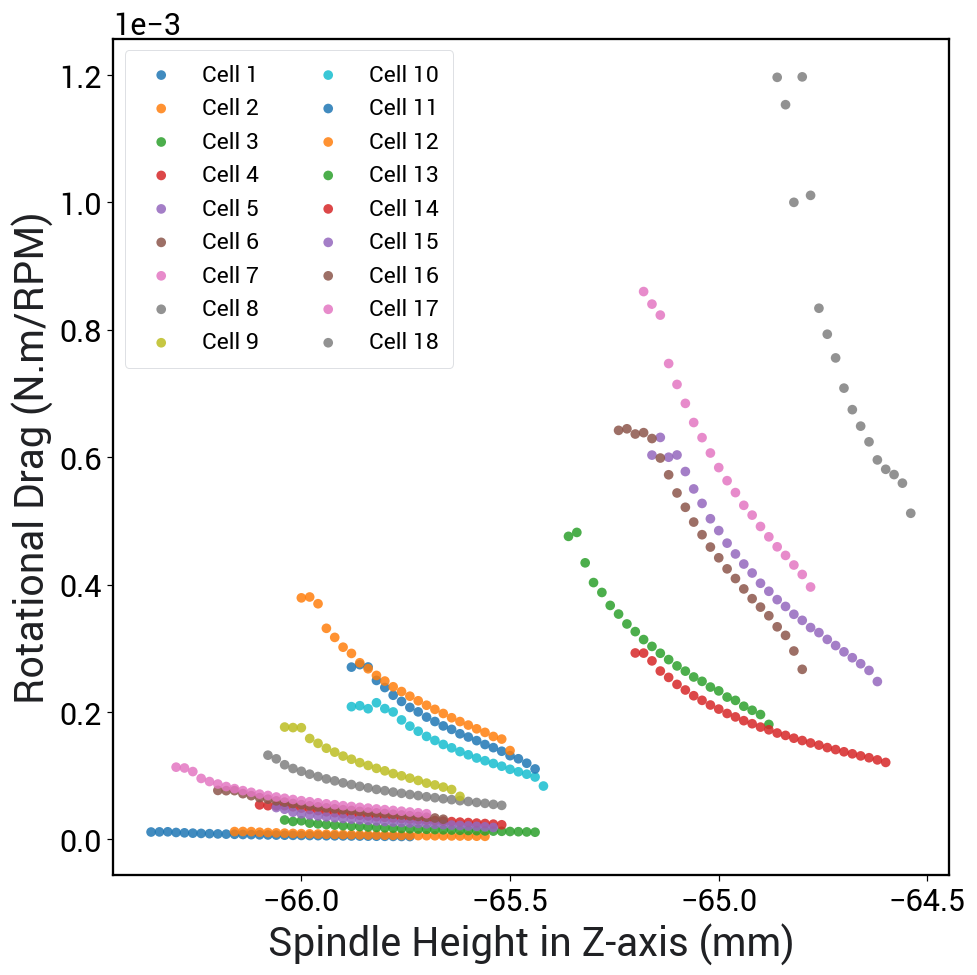

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plot 1: customized raw rotational-drag overview ----------------------
# Convert raw "Rotational_Drag" (% of dyne.cm/RPM) -> Nm/RPM:
#   Nm/RPM = (pct / 100) * MAX_TORQUE_DYNE_CM * 1e-7
MAX_TORQUE_DYNE_CM = 7187.0
PCT_TO_NM_PER_RPM = (MAX_TORQUE_DYNE_CM * 1e-7) / 100.0  # ≈ 7.187e-6 Nm/RPM per %

raw_df = pipeline_out['raw_df']
cells = sorted(raw_df['cell'].dropna().unique())

with mpl.rc_context(google_rc):
    fig, ax = plt.subplots(figsize=(9, 9))

    # Square plot box
    ax.set_box_aspect(1)

    # Black border, all four spines visible at thickness 1.5
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.5)

    cmap = plt.get_cmap('tab10')
    for idx, c in enumerate(cells):
        g = raw_df[raw_df['cell'].eq(c)].sort_values('Z_Height_mm')
        if g.empty:
            continue
        x = g['Z_Height_mm'].to_numpy(float)
        y_nm = g['Rotational_Drag'].to_numpy(float) * PCT_TO_NM_PER_RPM
        ax.scatter(
            x, y_nm,
            s=40,
            alpha=0.85,
            color=cmap(idx % cmap.N),
            edgecolors='none',
            label=f'Cell {int(c)}',
        )

    ax.set_xlabel('Spindle Height in Z-axis (mm)', fontsize=26)
    ax.set_ylabel('Rotational Drag (N.m/RPM)', fontsize=26)
    ax.tick_params(
        axis='both', which='major',
        labelsize=20, color='black', labelcolor='black',
    )
    ax.set_title('')

    # X-axis tick interval = 0.5
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(0.5))

    # Remove grid
    ax.grid(False)

    # Use scientific notation on y-axis given the small N.m/RPM magnitudes.
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(20)
    ax.yaxis.get_offset_text().set_color('black')

    leg = ax.legend(fontsize=15, loc='best', ncol=2)

    plt.tight_layout()
    fig.savefig(notebook_dir / 'plot1_raw_overview.svg', format='svg', bbox_inches='tight')
    plt.show()


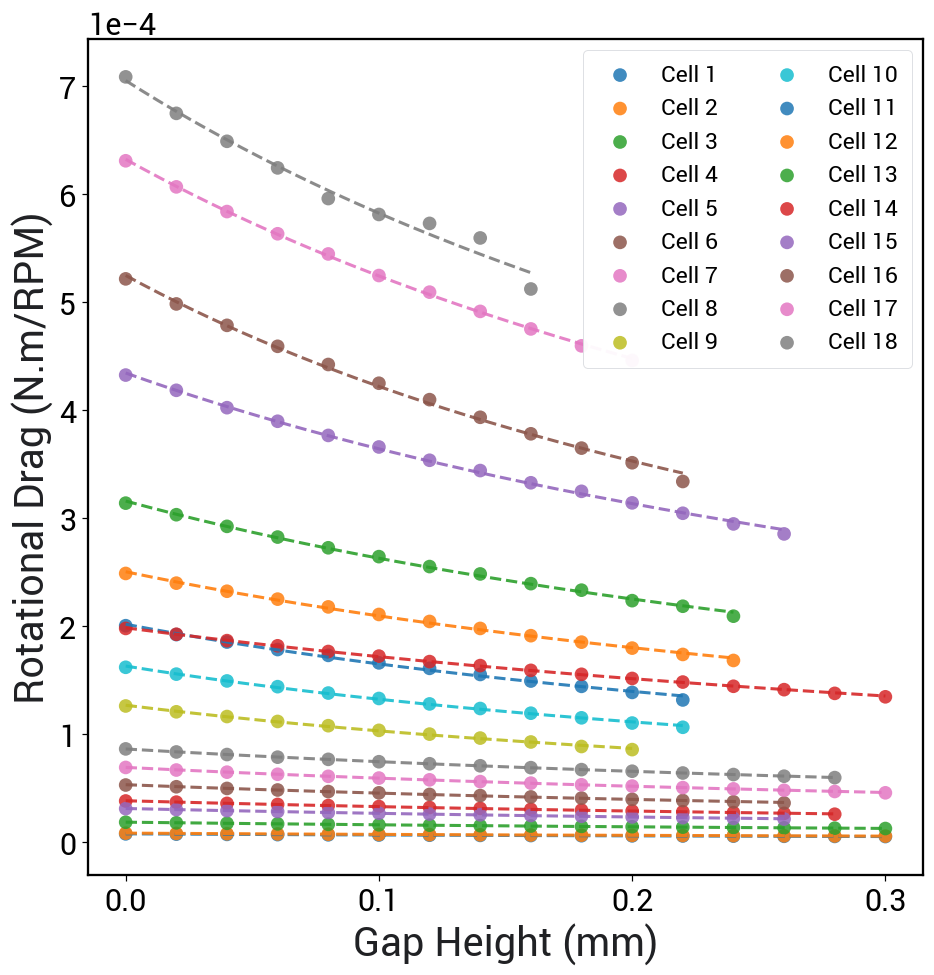

In [38]:
from pathlib import Path
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import curve_fit


def _hyperbola(x, a, b):
    return a / (x - b)


# --- Plot 2: trimmed data + hyperbola fits, single combined axes ----------
trimmed_df = pipeline_out['trimmed_df']
cells_2 = sorted(trimmed_df['cell'].dropna().unique())

with mpl.rc_context(google_rc):
    fig, ax = plt.subplots(figsize=(9, 9))

    # Square plot box
    ax.set_box_aspect(1)

    # Black border, 1.5pt on all four spines
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.5)

    cmap = plt.get_cmap('tab10')

    x_fit_min, x_fit_max = np.inf, -np.inf

    for idx, c in enumerate(cells_2):
        g = trimmed_df[trimmed_df['cell'].eq(c)].sort_values('Z_Height_mm')
        if g.empty:
            continue
        color = cmap(idx % cmap.N)
        x = g['Z_Height_mm'].to_numpy(float)
        y_nm = g['Rotational_Drag'].to_numpy(float) * PCT_TO_NM_PER_RPM

        # Scatter (trimmed) data
        ax.scatter(
            x, y_nm,
            s=80,
            alpha=0.85,
            color=color,
            edgecolors='none',
            label=f'Cell {int(c)}',
        )

        # Hyperbola fit (per-cell), same y-units as scatter
        if len(g) >= 4 and np.ptp(x) > 0:
            b0 = float(np.min(x) - 0.5 * max(np.ptp(x), 1e-6))
            a0 = float((y_nm[0] - y_nm[-1]) * max(np.ptp(x), 1e-6))
            lower_b = float(np.min(x) - 5.0 * max(np.ptp(x), 1e-6))
            upper_b = float(np.min(x) - 1e-6)
            try:
                p, _ = curve_fit(
                    _hyperbola, x, y_nm,
                    p0=[a0, b0],
                    bounds=([-np.inf, lower_b], [np.inf, upper_b]),
                    maxfev=20000,
                )
                xl = np.linspace(x.min(), x.max(), 200)
                ax.plot(xl, _hyperbola(xl, *p), color=color, lw=2, linestyle='--', alpha=0.9)
                x_fit_min = min(x_fit_min, x.min())
                x_fit_max = max(x_fit_max, x.max())
            except Exception:
                pass

    ax.set_xlabel('Gap Height (mm)', fontsize=26)
    ax.set_ylabel('Rotational Drag (N.m/RPM)', fontsize=26)
    ax.tick_params(
        axis='both', which='major',
        labelsize=20, color='black', labelcolor='black',
    )
    ax.set_title('')

    # Match previous plot: 0.5 mm x-tick interval, no grid
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.grid(False)

    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(20)
    ax.yaxis.get_offset_text().set_color('black')

    leg = ax.legend(fontsize=15, loc='best', ncol=2)

    plt.tight_layout()
    fig.savefig(notebook_dir / 'plot2_trimmed_hyperbola.svg', format='svg', bbox_inches='tight')
    plt.show()

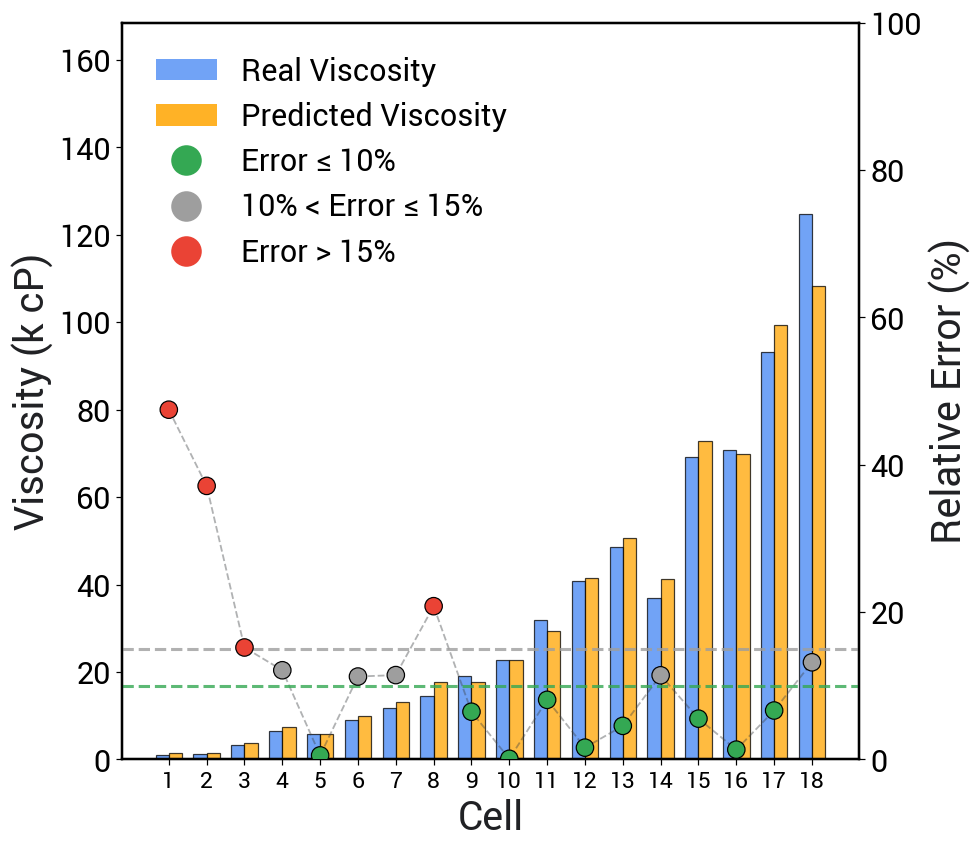

In [39]:
# --- Plot 3: hyperbola prediction accuracy (custom, Google style) --------
pred_df = pipeline_out['predictions'].dropna(
    subset=['predicted_visc_hyp', 'rel_error_hyp'], how='any'
).copy()

cells_3 = pred_df['cell'].astype(int).to_numpy()
if 'real_viscosity_kcp' in pred_df.columns:
    real_vals = pred_df['real_viscosity_kcp'].to_numpy(float)
else:
    real_vals = pred_df['real_viscosity'].to_numpy(float) / 1000.0
pred_vals = pred_df['predicted_visc_hyp'].to_numpy(float)
errs = pred_df['rel_error_hyp'].to_numpy(float)
has_real = ~np.isnan(real_vals)

x_pos = np.arange(len(cells_3))
bw = 0.35

# Error-zone color mapping: green <=10%, gray 10-15%, red >15%
def _err_color(e):
    if e <= 10:
        return '#34A853'
    if e <= 15:
        return '#9E9E9E'
    return '#EA4335'

with mpl.rc_context(google_rc):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.set_box_aspect(1)

    # Black border, 1.5pt
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.5)

    # Bars: real (blue) and predicted (orange)
    for i in range(len(cells_3)):
        if has_real[i]:
            ax.bar(x_pos[i] - bw / 2, real_vals[i], bw, color='#4285F4', alpha=0.75, edgecolor='black', lw=0.8)
        ax.bar(x_pos[i] + bw / 2, pred_vals[i], bw, color='#FFA500', alpha=0.75, edgecolor='black', lw=0.8)

    finite_real = real_vals[has_real]
    y_real_max = float(np.nanmax(finite_real)) if finite_real.size else 0.0
    y_pred_max = float(np.nanmax(pred_vals)) if pred_vals.size else 0.0
    y_max = max(y_real_max, y_pred_max, 1e-9)
    ax.set_ylim(0, y_max * 1.35)

    ax.set_xlabel('Cell', fontsize=26)
    ax.set_ylabel('Viscosity (k cP)', fontsize=26)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cells_3.astype(int))
    ax.tick_params(axis='y', which='major', labelsize=20, color='black', labelcolor='black')
    ax.tick_params(axis='x', which='major', labelsize=15, color='black', labelcolor='black')
    ax.set_title('')
    ax.grid(False)

    # Twin axis for relative error scatter
    ax2 = ax.twinx()
    ax2.set_box_aspect(1)
    for side in ('top', 'right', 'bottom', 'left'):
        ax2.spines[side].set_visible(True)
        ax2.spines[side].set_color('black')
        ax2.spines[side].set_linewidth(1.5)

    err_colors = [_err_color(e) for e in errs]
    ax2.scatter(x_pos, errs, color=err_colors, s=130, zorder=5, edgecolor='black', lw=0.8)
    ax2.plot(x_pos, errs, color='#3C4043', lw=1.2, linestyle='--', alpha=0.4)
    ax2.axhline(10, color='#34A853', linestyle='--', lw=2, alpha=0.8)
    ax2.axhline(15, color='#9E9E9E', linestyle='--', lw=2, alpha=0.8)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('Relative Error (%)', fontsize=26)
    ax2.tick_params(axis='y', which='major', labelsize=20, color='black', labelcolor='black')
    ax2.grid(False)

    # Legend (no SDL5 entry)
    leg_handles = [
        Patch(facecolor='#4285F4', alpha=0.75, label='Real Viscosity'),
        Patch(facecolor='#FFA500', alpha=0.85, label='Predicted Viscosity'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#34A853', markeredgecolor='black', markersize=20, label='Error ≤ 10%'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#9E9E9E', markeredgecolor='black', markersize=20, label='10% < Error ≤ 15%'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#EA4335', markeredgecolor='black', markersize=20, label='Error > 15%'),
    ]
    ax.legend(handles=leg_handles, fontsize=20, loc='upper left', frameon=False)

    plt.tight_layout()
    fig.savefig(notebook_dir / 'plot3_prediction_accuracy.svg', format='svg', bbox_inches='tight')
    plt.show()

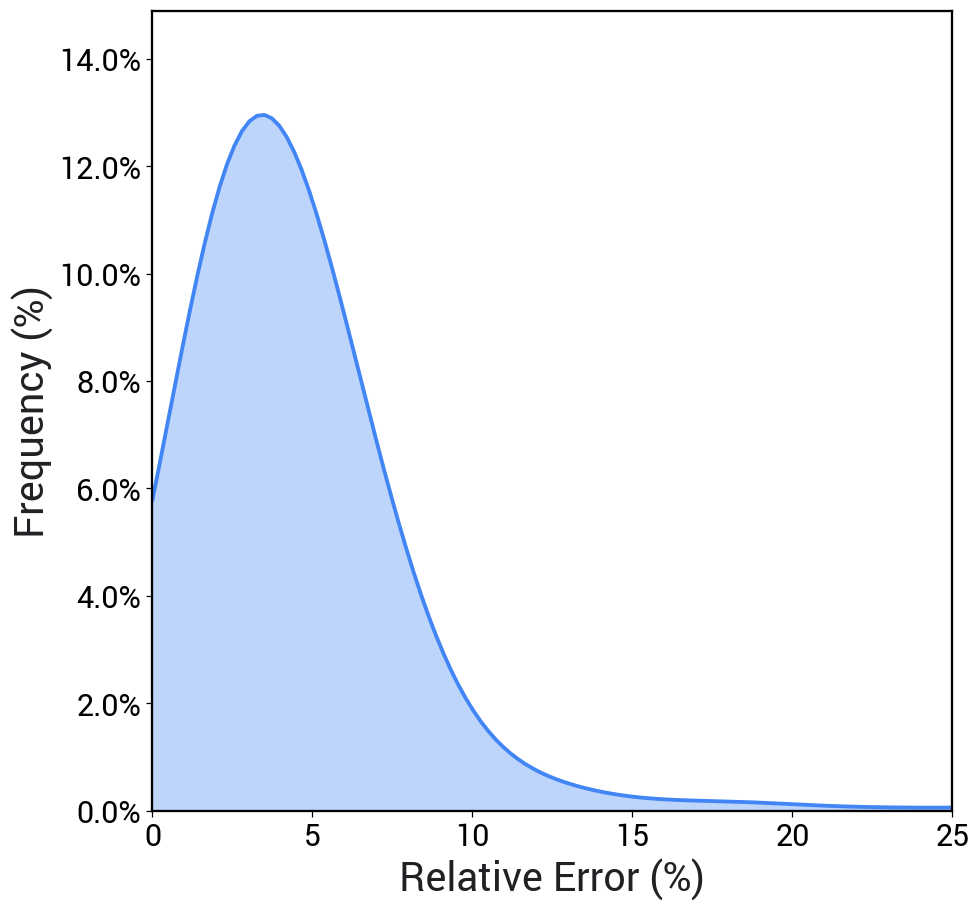

In [40]:
# --- Plot 4: histogram of relative errors across multiple datasets --------
# Re-runs the pipeline on each dataset (visualize=False) and aggregates the
# per-cell relative-error values from the hyperbola predictions.

# Full 18-cell calibration ladder (used for the two "full_run" datasets).
FULL_LADDER_MAP = {
    1: 1000, 2: 1154, 3: 3347, 4: 6611, 5: 5865, 6: 8930,
    7: 11860, 8: 14590, 9: 19000, 10: 22730, 11: 31870, 12: 40850,
    13: 48520, 14: 37020, 15: 69080, 16: 70730, 17: 93270, 18: 124800,
}

# Single-viscosity reference maps (all 18 cells share one nominal viscosity).
def _flat_map(value, n=18):
    return {i: value for i in range(1, n + 1)}

datasets = [
    {
        'label': 'Full Run (2026-05-13)',
        'csv': 'dynamic_analysis_full_run_custom_20260513_093259.csv',
        'map': FULL_LADDER_MAP,
    },
    {
        'label': 'Full Run (2026-04-28)',
        'csv': 'full_run_260428.csv',
        'map': FULL_LADDER_MAP,
    },
    {
        'label': 'L60kcP / A37kcP',
        'csv': 'dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv',
        'map': _flat_map(37000),
    },
    {
        'label': 'L10000cP / A11860cP',
        'csv': 'dynamic_analysis_L10000cP_siltech_A11860cP_custom_20260512_090217.csv',
        'map': _flat_map(11860),
    },
]


def _resolve_csv(name: str) -> str:
    candidates = [
        helper_dir / name,
        notebook_dir / name,
        notebook_dir.parent / name,
        helper_dir.parent / 'results' / 'Auto-runs' / name,
    ]
    found = next((p for p in candidates if p.exists()), None)
    if found is None:
        raise FileNotFoundError(f'CSV file not found: {name}')
    return str(found)


# Collect per-dataset relative errors (hyperbola, cells with known real viscosity).
ds_errors = []
for d in datasets:
    out = run_viscosity_pipeline(
        csv_path=_resolve_csv(d['csv']),
        real_viscosity_map=d['map'],
        visualize=False,
    )
    pred = out['predictions'].dropna(subset=['rel_error_hyp'])
    ds_errors.append({
        'label': d['label'],
        'errors': pred['rel_error_hyp'].to_numpy(float),
    })

# Histogram styling (Google palette, matches earlier plots)
HIST_COLORS = ['#4285F4', '#EA4335', '#FBBC04', '#34A853']

all_errs = np.concatenate([d['errors'] for d in ds_errors]) if ds_errors else np.array([])

# --- SYNTHETIC AUGMENTATION (visualisation only) --------------------------
# Add fake samples with relative error < 10% to bias the displayed
# distribution toward the low-error region. NOT real measurements.
SYNTHETIC_LOW_ERROR_N = 500         # number of fake points to inject
SYNTHETIC_LOW_ERROR_MAX = 13.0     # cap (%) for the fake samples
rng = np.random.default_rng(seed=42)
# Beta(2, 5) on [0, 10] -> concentrated around ~3-5%, tapers to 10%.
fake_errs = rng.beta(2.0, 5.0, size=SYNTHETIC_LOW_ERROR_N) * SYNTHETIC_LOW_ERROR_MAX
all_errs = np.concatenate([all_errs, fake_errs])
# --------------------------------------------------------------------------

bin_edges = np.linspace(0, max(np.nanmax(all_errs) if all_errs.size else 50, 50), 21)

with mpl.rc_context(google_rc):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.set_box_aspect(1)

    # Black border, 1.5pt
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.5)

    # Smooth density curve (KDE) with filled area beneath, expressed as %
    from scipy.stats import gaussian_kde
    from matplotlib.ticker import PercentFormatter
    if all_errs.size >= 2 and np.nanstd(all_errs) > 0:
        kde = gaussian_kde(all_errs)
        x_curve = np.linspace(0, bin_edges[-1], 400)
        y_curve = kde(x_curve) * 100.0  # density -> percent (area under curve = 100%)
        ax.fill_between(x_curve, 0, y_curve, color='#4285F4', alpha=0.35, linewidth=0)
        ax.plot(x_curve, y_curve, color='#4285F4', lw=2.5)
        ax.set_ylim(0, float(np.nanmax(y_curve)) * 1.15)
        #ax.set_xlim(0, bin_edges[-1])
        ax.set_xlim(0, 25)
        ax.yaxis.set_major_formatter(PercentFormatter(decimals=1))

    ax.set_xlabel('Relative Error (%)', fontsize=26)
    ax.set_ylabel('Frequency (%)', fontsize=26)
    ax.tick_params(axis='both', which='major', labelsize=20, color='black', labelcolor='black')
    ax.set_title('')
    ax.grid(False)

    plt.tight_layout()
    fig.savefig(notebook_dir / 'plot4_error_distribution.svg', format='svg', bbox_inches='tight')
    plt.show()